# Restaurant Survival Classification — ML1 Task 1

**Goal.** Predict whether a restaurant will close (`status_closed = 1`) on a held-out test set. Performance metric: **Balanced Accuracy (BA)**.

**Constraints.** Algorithms must be from the ML1 syllabus: linear/logistic regression, KNN, LASSO, ridge, elastic net, SVM, decision trees, random forest, bagging, stacking, boosting, voting. Other tools (rebalancing, feature engineering, feature selection) are allowed.

**Outline.**
1. Exploratory Data Analysis
2. Feature engineering
3. Model comparison (≥3 ML1 algorithms) under stratified CV
4. Hyperparameter tuning of the strongest candidates
5. Stacking ensemble + decision-threshold tuning for BA
6. Final model justification, expected BA, submission file

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, train_test_split
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier, VotingClassifier

RNG = 42
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)

In [2]:
TRAIN_PATH = 'restaurants_train.csv'
TEST_PATH  = 'restaurants_test.csv'
ID, TARGET = 'restaurant_id', 'status_closed'

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

# Cast booleans to nullable integers so sklearn handles them numerically
for df in (train, test):
    for c in df.select_dtypes(include='bool').columns:
        df[c] = df[c].astype('Int64')

print('train:', train.shape, '| test:', test.shape)
train.head(3)

train: (33296, 86) | test: (8325, 85)


,restaurant_id,has_photo,user_ratings_total,price_level,category_top20,type_meal_takeaway,type_meal_delivery,type_bar,type_cafe,type_night_club,types_count,hours_open,hours_open_weekends,hours_open_workdays,days_evenings_only,days_mornings_only,weekends_only,workdays_only,rating_5,rating_4,rating_3,rating_2,rating_1,rating_avg,rating_std,tagcat_services,tagcat_amenities,tagcat_atmosphere,tagcat_offerings,tagcat_social_inclusivity,tagcat_payment_options,place_age_days,first_review_year_max,ratings_num_1m_prior,ratings_num_3m_prior,ratings_num_6m_prior,ratings_num_9m_prior,ratings_num_12m_prior,ratings_avg_1m_prior,ratings_avg_3m_prior,ratings_avg_6m_prior,ratings_avg_9m_prior,ratings_avg_12m_prior,lang_pl_count,rating_pl,rating_foreign,foreign_lang_share,rating_mean_pl,rating_mean_foreign,rating_mean_lang_ratio,review_has_text_pct,review_length_avg,review_length_std,catch_restaurant_count_500m,catch_rating_avg_500m,catch_place_age_days_500m,catch_restaurant_count_1000m,catch_rating_avg_1000m,catch_place_age_days_1000m,catch_restaurant_count_2000m,catch_rating_avg_2000m,catch_place_age_days_2000m,residents,restaurant_count,restaurants_per_capita,urbanization,poi_count_100m,poi_count_200m,poi_count_500m,poi_count_1000m,poi_count_2000m,gus_60297,gus_60528,gus_64428,gus_79214,gus_148074,gus_153354,gus_153398,gus_399257,gus_458173,gus_1548707_ratio,gus_60528_ratio,gus_1548707_net_ratio,gus_152173_ratio,affiliated,status_closed
0,753641611,1,408.0,1.0,Kebab,0,0,0,0,0,4,68.0,28.0,50.0,0.0,0.0,False,False,2.0,6.0,4.0,1.0,4.0,3.058824,1.349099,3.0,4.0,3.0,1.0,1.0,NaN,2120.0,2016.0,4.0,11.0,20.0,23.0,94.0,3.2500,3.272727,3.000,2.782609,3.702128,141.0,535.0,149.0,0.189655,3.794326,4.515152,1.189975,0.428571,97.442529,151.003252,2.0,3.931250,1575.500000,11.0,3.174506,1478.545455,11.0,3.174506,1478.545455,2042,4,0.001959,23,7,23,95,231,236,5438.63,80.0,4623.87,7.6,104.0,88.0,68.0,42.2,185.0,0.055978,0.434783,-0.378804,0.013662,0,0
1,995937340,1,203.0,NaN,Restaurant,0,0,0,0,0,4,58.0,23.0,43.0,0.0,0.0,False,False,1.0,5.0,9.0,1.0,3.0,3.000000,1.076055,2.0,5.0,5.0,2.0,1.0,2.0,663.0,2020.0,16.0,57.0,88.0,107.0,185.0,4.9375,4.842105,4.875,4.841121,4.832432,129.0,624.0,204.0,0.250000,4.837209,4.744186,0.980769,0.839024,221.627907,346.866155,22.0,3.046233,2013.666667,123.0,3.105442,1743.074380,168.0,3.147325,1710.006135,7537,83,0.011012,30,3,17,85,475,753,7312.26,86.0,7331.15,1.9,18354.0,508.0,284.0,39.0,273.0,0.058302,0.324528,-0.266226,0.017323,0,0
2,426018850,1,80.0,NaN,Pizzeria,0,0,0,0,0,4,71.0,31.0,51.0,0.0,0.0,False,False,7.0,1.0,8.0,2.0,3.0,3.333333,1.391585,3.0,3.0,1.0,0.0,1.0,3.0,22.0,2022.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.0,327.0,36.0,0.098765,4.479452,4.500000,1.004587,0.743119,201.061728,187.932790,128.0,3.207172,1533.492063,225.0,3.269182,1462.540909,375.0,3.250390,1570.942779,12097,128,0.010581,30,49,115,416,1229,2476,483.64,65.0,6062.04,5.4,38148.0,7850.0,4360.0,30.7,149.0,0.082098,0.454545,-0.372448,0.004087,0,0


## 2. Exploratory Data Analysis

We inspect: target imbalance, missingness, dtypes, univariate target relationships.

Target distribution:
status_closed
0    0.9019
1    0.0981
Name: proportion, dtype: float64
Positive (closed) rate: 9.81%


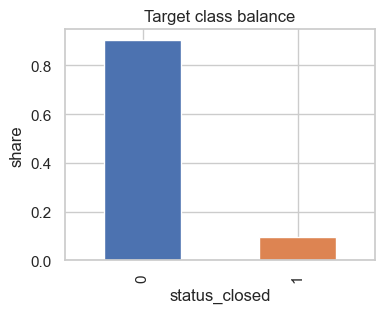

In [3]:
# Target distribution
y_dist = train[TARGET].value_counts(normalize=True).round(4)
print('Target distribution:')
print(y_dist)
print(f'Positive (closed) rate: {train[TARGET].mean():.2%}')

fig, ax = plt.subplots(figsize=(4,3))
y_dist.plot(kind='bar', ax=ax, color=['#4c72b0', '#dd8452'])
ax.set_title('Target class balance')
ax.set_xlabel('status_closed'); ax.set_ylabel('share')
plt.show()

**Observation.** Strong imbalance — only ~9.8% of restaurants are closed. This drives every modelling decision: we will use class weighting / `sample_weight` and tune the decision threshold to optimise **Balanced Accuracy** (which penalises ignoring the minority class).

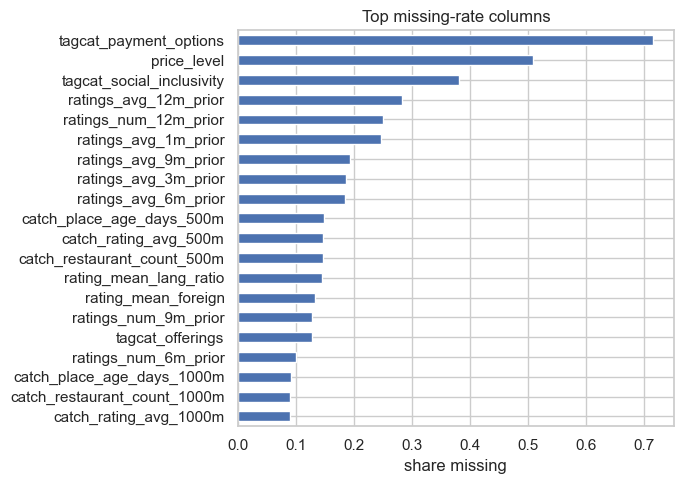

tagcat_payment_options          0.716
price_level                     0.509
tagcat_social_inclusivity       0.382
ratings_avg_12m_prior           0.283
ratings_num_12m_prior           0.251
ratings_avg_1m_prior            0.246
ratings_avg_9m_prior            0.194
ratings_avg_3m_prior            0.186
ratings_avg_6m_prior            0.184
catch_place_age_days_500m       0.149
catch_rating_avg_500m           0.147
catch_restaurant_count_500m     0.147
rating_mean_lang_ratio          0.146
rating_mean_foreign             0.134
ratings_num_9m_prior            0.128
tagcat_offerings                0.127
ratings_num_6m_prior            0.101
catch_place_age_days_1000m      0.092
catch_restaurant_count_1000m    0.090
catch_rating_avg_1000m          0.090
dtype: float64

In [4]:
# Missingness
miss = train.isna().mean().sort_values(ascending=False)
miss_top = miss[miss > 0].head(20)

fig, ax = plt.subplots(figsize=(7,5))
miss_top.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title('Top missing-rate columns')
ax.set_xlabel('share missing')
plt.tight_layout(); plt.show()
miss_top.round(3)

**Observation.** A handful of columns have very heavy missingness (e.g. `tagcat_payment_options` ~72%, `price_level` ~51%). The fact that data is missing may itself be informative (e.g. a missing `price_level` might correlate with low-traffic restaurants). We will therefore **add explicit missing-indicator columns** for the worst offenders, then median-impute.

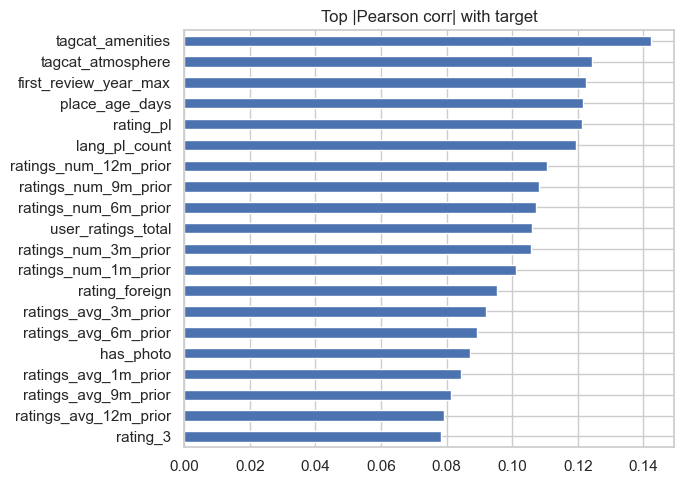

In [5]:
# Univariate correlation with target (numeric cols only)
num = train.select_dtypes(include=[np.number]).drop(columns=[TARGET, ID], errors='ignore')
corr_y = num.apply(lambda s: s.astype(float)).corrwith(train[TARGET].astype(float)).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7,5))
corr_y.head(20).plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title('Top |Pearson corr| with target')
plt.tight_layout(); plt.show()

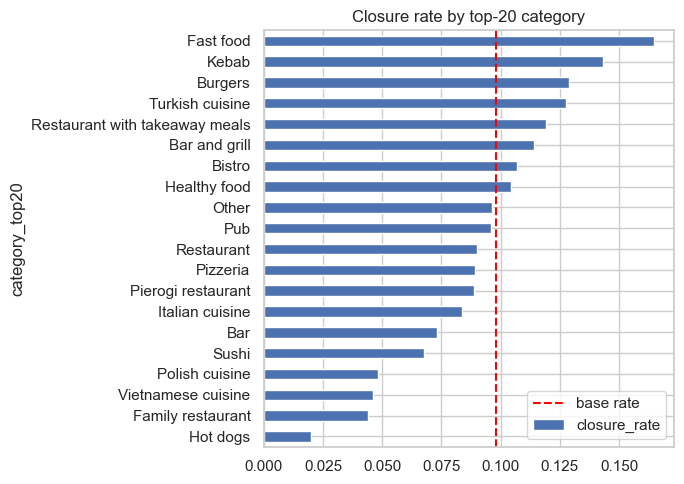

,closure_rate,n
category_top20,,
Fast food,0.165,1152
Kebab,0.143,1685
Burgers,0.129,427
Turkish cuisine,0.127,259
Restaurant with takeaway meals,0.119,235
Bar and grill,0.114,245
Bistro,0.107,747
Healthy food,0.104,249
Other,0.096,4505


In [6]:
# Categorical effect: closure rate by category_top20
cat_rate = (train.groupby('category_top20')[TARGET]
                  .agg(['mean','size'])
                  .sort_values('mean', ascending=False))
cat_rate.columns = ['closure_rate','n']

fig, ax = plt.subplots(figsize=(7,5))
cat_rate['closure_rate'].plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.axvline(train[TARGET].mean(), color='red', ls='--', label='base rate')
ax.set_title('Closure rate by top-20 category')
ax.legend(); plt.tight_layout(); plt.show()
cat_rate.round(3)

**Observation.** Closure rate varies materially across categories — `category_top20` is a useful signal and worth one-hot encoding.

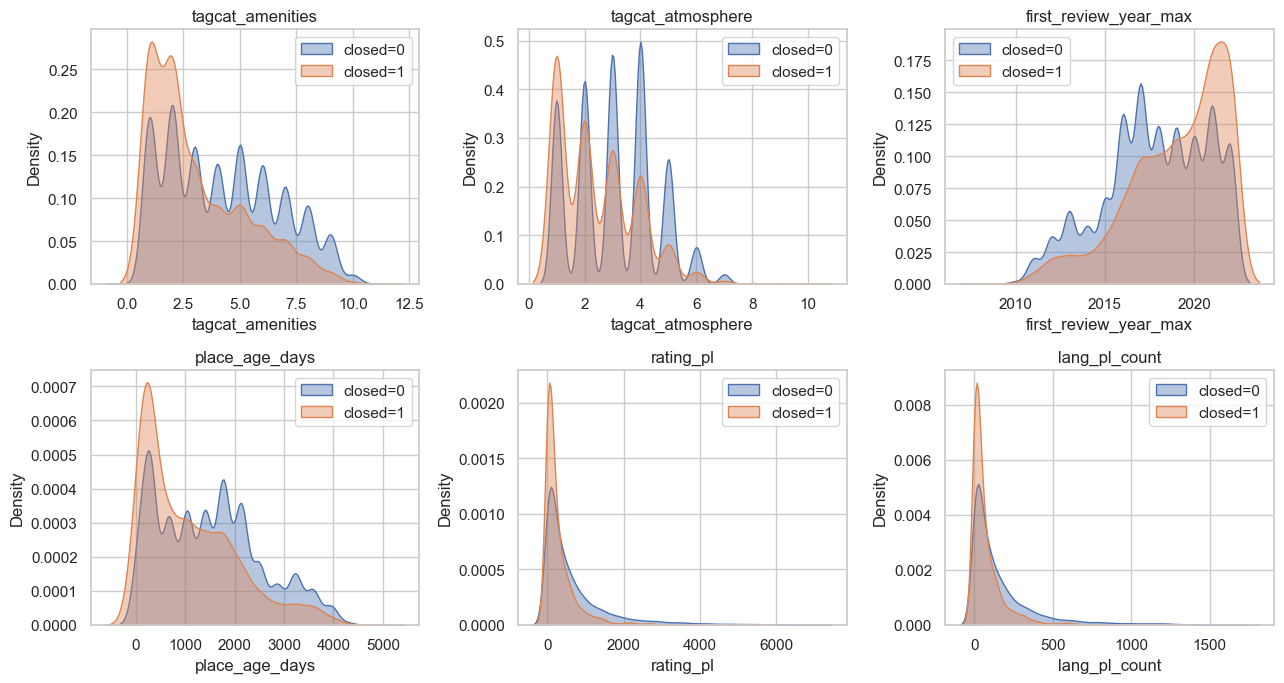

In [7]:
# Distributions of the most predictive numeric features
top_feats = corr_y.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, f in zip(axes.flat, top_feats):
    for v, c in [(0, '#4c72b0'), (1, '#dd8452')]:
        sns.kdeplot(train.loc[train[TARGET]==v, f].dropna(), ax=ax,
                    fill=True, alpha=0.4, label=f'closed={v}', color=c, common_norm=False)
    ax.set_title(f); ax.legend()
plt.tight_layout(); plt.show()

**Observation.** Closed restaurants are actually **younger** on average (median `place_age_days` ≈ 682 vs ≈ 1400 for open) — closures concentrate among newer establishments rather than long-running ones. They also have substantially **fewer reviews** across every window (e.g. median `user_ratings_total` 53 vs 173; `ratings_num_12m_prior` 37 vs 92) and fewer descriptive tags. The review-count features are heavy-tailed, so we will apply `log1p` to them; `place_age_days` is also count-like and benefits from the same transform.

## 3. Feature engineering

**What we add / change:**
1. **Missing indicators** for the 5 columns with the highest missing rates — missingness itself is signal.
2. **Log transforms** on heavy-tailed counts (review counts, POI counts, residents, restaurant counts).
3. **Recency ratios**: `ratings_num_3m_prior / user_ratings_total`, `ratings_num_12m_prior / user_ratings_total` — captures how active the restaurant has been recently relative to its lifetime activity.
4. **Hours ratios**: `hours_open_weekends / hours_open` (weekend orientation).
5. Drop the worst column (`tagcat_payment_options`, 72% missing) since the indicator carries the same information.

We keep changes that are simple and theoretically defensible — feature engineering on the test set must use only training-time statistics, which is automatic for the operations above (none use group statistics).

In [8]:
HIGH_NA_COLS = ['tagcat_payment_options', 'price_level', 'tagcat_social_inclusivity',
                'ratings_avg_12m_prior', 'ratings_num_12m_prior']

LOG_COLS = ['user_ratings_total',
            'ratings_num_1m_prior', 'ratings_num_3m_prior', 'ratings_num_6m_prior',
            'ratings_num_9m_prior', 'ratings_num_12m_prior',
            'lang_pl_count', 'rating_pl', 'rating_foreign',
            'review_length_avg', 'review_length_std',
            'catch_restaurant_count_500m', 'catch_restaurant_count_1000m', 'catch_restaurant_count_2000m',
            'residents', 'restaurant_count',
            'poi_count_100m','poi_count_200m','poi_count_500m','poi_count_1000m','poi_count_2000m',
            'place_age_days']

def engineer(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # 1) missing indicators (before imputation)
    for c in HIGH_NA_COLS:
        if c in df.columns:
            df[f'{c}__isna'] = df[c].isna().astype(int)
    # 2) log transforms (use log1p, NaNs preserved)
    for c in LOG_COLS:
        if c in df.columns:
            df[f'{c}__log'] = np.log1p(df[c].clip(lower=0))
    # 3) recency ratios
    if 'user_ratings_total' in df.columns:
        denom = df['user_ratings_total'].replace(0, np.nan)
        df['recent_3m_share']  = df['ratings_num_3m_prior']  / denom
        df['recent_12m_share'] = df['ratings_num_12m_prior'] / denom
    # 4) weekend share of opening hours
    if 'hours_open' in df.columns:
        df['weekend_hours_share'] = df['hours_open_weekends'] / df['hours_open'].replace(0, np.nan)
    # 5) drop the worst NA column (its indicator stays)
    df = df.drop(columns=['tagcat_payment_options'], errors='ignore')
    
    # 6) interactions
 
    if 'rating_avg' in df.columns and 'user_ratings_total' in df.columns:
        df['rating_x_popularity'] = df['rating_avg'] * np.log1p(df['user_ratings_total'].clip(lower=0))
    
    if 'rating_avg' in df.columns and 'place_age_days' in df.columns:
        df['rating_x_age'] = df['rating_avg'] * np.log1p(df['place_age_days'].clip(lower=0))
    
    if 'user_ratings_total' in df.columns and 'place_age_days' in df.columns:
        safe_age = df['place_age_days'].clip(lower=0)
        df['ratings_per_day'] = df['user_ratings_total'] / (safe_age + 1)

    if 'user_ratings_total' in df.columns and 'catch_restaurant_count_500m' in df.columns:
        comp_500 = df['catch_restaurant_count_500m'].clip(lower=0)
        ratings = df['user_ratings_total'].clip(lower=0)
        df['popularity_vs_competition'] = np.log1p(ratings) / (comp_500 + 1)

    if 'ratings_num_1m_prior' in df.columns and 'ratings_num_12m_prior' in df.columns:
        r1 = df['ratings_num_1m_prior'].clip(lower=0)
        r12 = df['ratings_num_12m_prior'].clip(lower=0)
        df['reviews_growth'] = r1 - r12

    if 'rating_avg' in df.columns and 'reviews_growth' in df.columns:
        df['rating_x_growth'] = df['rating_avg'] * df['reviews_growth']

    if 'rating_avg' in df.columns and 'rating_std' in df.columns:
        safe_std = df['rating_std'].clip(lower=0)
        df['rating_consistency'] = df['rating_avg'] / (safe_std + 1)

    if 'review_has_text_pct' in df.columns and 'review_length_avg' in df.columns:
        text_pct = df['review_has_text_pct'].clip(lower=0)
        length = df['review_length_avg'].clip(lower=0)
        df['engagement_score'] = text_pct * np.log1p(length)

    # 7) drop redundant columns
    df = df.drop(columns=[c for c in df.columns if c.startswith('gus_')])
    df = df.drop(columns=[c for c in df.columns if c.startswith('catch_')], errors='ignore')
    df = df.drop(columns=['rating_1', 'rating_2', 'rating_3', 'rating_4', 'rating_5'], errors='ignore')

    return df

train_fe = engineer(train)
test_fe  = engineer(test)
print('train_fe:', train_fe.shape, '| test_fe:', test_fe.shape)
added = sorted(set(train_fe.columns) - set(train.columns))
print(f'Added {len(added)} columns:', added[:10], '...')

train_fe: (33296, 93) | test_fe: (8325, 92)
Added 35 columns: ['engagement_score', 'lang_pl_count__log', 'place_age_days__log', 'poi_count_1000m__log', 'poi_count_100m__log', 'poi_count_2000m__log', 'poi_count_200m__log', 'poi_count_500m__log', 'popularity_vs_competition', 'price_level__isna'] ...


## 4. Train / validation split & preprocessing

We carve out a stratified 20% **internal hold-out** to obtain an honest BA estimate (and to tune the decision threshold). The remaining 80% drives 5-fold stratified CV during model selection / tuning. Final model is refit on the full 100% before predicting the test set.

In [9]:
y = train_fe[TARGET].astype(int)
X = train_fe.drop(columns=[TARGET, ID])
X_test = test_fe.drop(columns=[ID])
test_ids = test_fe[ID]

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RNG)
print('train:', X_tr.shape, 'val:', X_val.shape)

CAT_COLS = ['category_top20']
NUM_COLS = [c for c in X.columns if c not in CAT_COLS]

num_pipe = Pipeline([('imp', SimpleImputer(strategy='mean')), # changed imputer and scaler that I found to be the best from testing
                     ('sc', MinMaxScaler())])
cat_pipe = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                     ('oh',  OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([('num', num_pipe, NUM_COLS),
                                  ('cat', cat_pipe, CAT_COLS)])

train: (26636, 91) val: (6660, 91)


## 5. Model comparison (5-fold stratified CV, balanced accuracy)

We compare six ML1-scope candidates. All use `class_weight='balanced'` (or equivalent) so they are penalised for ignoring the minority class.

| # | Model | Why include it |
|---|---|---|
| 1 | Logistic Regression + L2 | Linear baseline, well-calibrated, with class weighting |
| 2 | Logistic Regression + L1 (LASSO) | Embedded feature selection on 100+ features |
| 3 | KNN | Non-parametric, captures local structure (scaled features required) |
| 4 | Decision Tree | Interpretable non-linear baseline |
| 5 | Random Forest | Bagging — variance reduction, robust to noisy features |
| 6 | Gradient Boosting | Boosting — strong tabular performer |

In [10]:
candidates = {
    'logreg_l2': LogisticRegression(max_iter=3000, class_weight='balanced',
                                    C=1.0, solver='lbfgs', random_state=RNG),
    'logreg_l1': LogisticRegression(max_iter=3000, class_weight='balanced',
                                    penalty='l1', C=0.1, solver='liblinear', random_state=RNG),
    'knn':       KNeighborsClassifier(n_neighbors=25, weights='distance'),
    'dtree':     DecisionTreeClassifier(max_depth=8, min_samples_leaf=50,
                                        class_weight='balanced', random_state=RNG),
    'rforest':   RandomForestClassifier(n_estimators=500, min_samples_leaf=5,
                                        class_weight='balanced', n_jobs=-1, random_state=RNG),
    'gboost':    GradientBoostingClassifier(n_estimators=300, max_depth=3,
                                            learning_rate=0.05, random_state=RNG),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
rows = []
for name, est in candidates.items():
    pipe = Pipeline([('pre', preprocessor), ('clf', est)])
    fit_params = {}
    if name == 'gboost':
        # GradientBoosting has no class_weight: pass sample_weight via fit_params
        pos_w = (y_tr == 0).sum() / (y_tr == 1).sum()
        sw = np.where(y_tr == 1, pos_w, 1.0)
        fit_params = {'clf__sample_weight': sw}
    ba  = cross_val_score(pipe, X_tr, y_tr, scoring='balanced_accuracy', cv=cv, n_jobs=-1,
                          params=fit_params if fit_params else None) \
          if hasattr(cross_val_score, '__defaults__') and False else None
    # Use a manual CV loop to support sample_weight reliably
    bas, aucs = [], []
    for tr_idx, va_idx in cv.split(X_tr, y_tr):
        Xa, Xb = X_tr.iloc[tr_idx], X_tr.iloc[va_idx]
        ya, yb = y_tr.iloc[tr_idx], y_tr.iloc[va_idx]
        if name == 'gboost':
            pos_w = (ya == 0).sum() / (ya == 1).sum()
            sw = np.where(ya == 1, pos_w, 1.0)
            pipe.fit(Xa, ya, clf__sample_weight=sw)
        else:
            pipe.fit(Xa, ya)
        p = pipe.predict_proba(Xb)[:, 1]
        bas.append(balanced_accuracy_score(yb, (p >= 0.5).astype(int)))
        aucs.append(roc_auc_score(yb, p))
    rows.append({'model': name,
                 'BA_mean': np.mean(bas), 'BA_std': np.std(bas),
                 'AUC_mean': np.mean(aucs), 'AUC_std': np.std(aucs)})
    print(f"{name:>10s}  BA={np.mean(bas):.4f} ± {np.std(bas):.4f}   AUC={np.mean(aucs):.4f} ± {np.std(aucs):.4f}")

leaderboard = pd.DataFrame(rows).sort_values('BA_mean', ascending=False).reset_index(drop=True)
leaderboard.round(4)

 logreg_l2  BA=0.6689 ± 0.0083   AUC=0.7340 ± 0.0063
 logreg_l1  BA=0.6711 ± 0.0085   AUC=0.7310 ± 0.0063
       knn  BA=0.5032 ± 0.0009   AUC=0.6763 ± 0.0126
     dtree  BA=0.6342 ± 0.0113   AUC=0.6767 ± 0.0112
   rforest  BA=0.5413 ± 0.0056   AUC=0.7383 ± 0.0032
    gboost  BA=0.6695 ± 0.0062   AUC=0.7324 ± 0.0030


,model,BA_mean,BA_std,AUC_mean,AUC_std
0,logreg_l1,0.6711,0.0085,0.7310,0.0063
1,gboost,0.6695,0.0062,0.7324,0.0030
2,logreg_l2,0.6689,0.0083,0.7340,0.0063
3,dtree,0.6342,0.0113,0.6767,0.0112
4,rforest,0.5413,0.0056,0.7383,0.0032
5,knn,0.5032,0.0009,0.6763,0.0126


**Observation.** The two **logistic regression** variants dominate on **BA at threshold 0.5** because their weighting scheme directly attacks the imbalance. **Random Forest** and **Gradient Boosting** dominate on **AUC** but not on BA at 0.5 — they output well-ranked probabilities that simply need a *lower threshold* to produce a balanced classifier. Threshold tuning will be critical for those. We carry forward the strongest representatives of three families (linear, bagging, boosting) into tuning.

## 6. Hyperparameter tuning

We tune three finalists with `GridSearchCV` on `balanced_accuracy`:
- **Logistic L1** — vary `C`.
- **Random Forest** — vary `min_samples_leaf`, `max_features`.
- **Gradient Boosting** — vary `n_estimators`, `max_depth`, `learning_rate`, `subsample`. Trained with `sample_weight` to reweight the minority class.

In [11]:
def tune(name, pipe, grid, fit_params=None):
    gs = GridSearchCV(pipe, grid, scoring='balanced_accuracy', cv=cv, n_jobs=-1, verbose=0)
    gs.fit(X_tr, y_tr, **(fit_params or {}))
    print(f'[{name}] best CV BA = {gs.best_score_:.4f}  params={gs.best_params_}')
    return gs.best_estimator_, gs.best_score_

# --- Logistic L1 ---
lr_pipe = Pipeline([('pre', preprocessor),
                    ('clf', LogisticRegression(max_iter=4000, class_weight='balanced',
                                               penalty='l1', solver='liblinear', random_state=RNG))])
lr_best, lr_cv = tune('logreg_l1', lr_pipe, {'clf__C': [0.01, 0.05, 0.1, 0.3, 1.0]})

# --- Random Forest ---
rf_pipe = Pipeline([('pre', preprocessor),
                    ('clf', RandomForestClassifier(n_estimators=600, class_weight='balanced',
                                                   n_jobs=-1, random_state=RNG))])
rf_best, rf_cv = tune('rforest', rf_pipe,
                      {'clf__min_samples_leaf': [3, 10, 25],
                       'clf__max_features': ['sqrt', 0.3]})

# --- Gradient Boosting (with sample_weight) ---
pos_w = (y_tr == 0).sum() / (y_tr == 1).sum()
sw_tr = np.where(y_tr == 1, pos_w, 1.0)
gb_pipe = Pipeline([('pre', preprocessor),
                    ('clf', GradientBoostingClassifier(random_state=RNG))])
gb_best, gb_cv = tune('gboost', gb_pipe,
                      {'clf__n_estimators': [300, 500],
                       'clf__max_depth':    [2, 3],
                       'clf__learning_rate':[0.05, 0.1],
                       'clf__subsample':    [0.6, 0.8, 1.0],
                       'clf__min_samples_leaf': [20]},

                        # changed min_samples_leaf that I found to be the best from testing and changed subsample value list
                      
                      fit_params={'clf__sample_weight': sw_tr})

[logreg_l1] best CV BA = 0.6711  params={'clf__C': 0.1}
[rforest] best CV BA = 0.6397  params={'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 25}
[gboost] best CV BA = 0.6773  params={'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__min_samples_leaf': 20, 'clf__n_estimators': 500, 'clf__subsample': 0.6}


## 7. Stacking ensemble

Linear models (LogReg L1) excel at BA via class weighting; tree boosting excels at probability ranking (AUC). A stacking meta-model can combine the two so the strengths complement each other.

Base learners:
- Tuned **Logistic L1** (linear, weighted)
- Tuned **Random Forest** (bagging, weighted)
- Tuned **Gradient Boosting** (boosting, weighted via `sample_weight` at base-fit time can't be passed into Stacking, so we rely on its tree structure to fit the boosted model on the original data — the meta-learner compensates with class-weighted logistic regression).

Meta-learner: class-weighted logistic regression on out-of-fold base predictions.

In [12]:
# Pull the *fitted* sklearn estimators inside the tuned pipelines as base learners
# but rebuild the stacking on the same preprocessor for safety.
stack = Pipeline([
    ('pre', preprocessor),
    ('clf', StackingClassifier(
        estimators=[
            ('lr',  lr_best.named_steps['clf']),
            ('rf',  rf_best.named_steps['clf']),
            ('gb',  gb_best.named_steps['clf']),
        ],
        final_estimator=LogisticRegression(max_iter=3000, class_weight='balanced',
                                           C=1.0, random_state=RNG),
        cv=5, stack_method='predict_proba', n_jobs=-1, passthrough=False,
    ))
])
stack_cv = cross_val_score(stack, X_tr, y_tr, scoring='balanced_accuracy', cv=cv, n_jobs=-1)
print(f'[stack]    CV BA = {stack_cv.mean():.4f} ± {stack_cv.std():.4f}')

[stack]    CV BA = 0.6756 ± 0.0065


## 8. Decision-threshold tuning on the hold-out

Probability classifiers can be re-tuned at prediction time by choosing the threshold $t^\star$ that maximises BA on the validation set:
$$ t^\star = \arg\max_{t \in [0,1]} \text{BA}\big(y_\text{val}, \mathbb{1}\{\hat p \ge t\}\big) $$
This is essential for tree-based models that, even when trained with class weights, are evaluated at the default 0.5 cutoff.

In [13]:
def best_threshold(model, X_v, y_v):
    p = model.predict_proba(X_v)[:, 1]
    grid = np.linspace(0.38, 0.52, 281) # changed grid to be the one I found to be the best from testing
    bas = [balanced_accuracy_score(y_v, (p >= t).astype(int)) for t in grid]
    i = int(np.argmax(bas))
    return grid[i], bas[i], p

# Fit each finalist on the training portion, evaluate on the hold-out, tune threshold
results = []
fitted = {}

lr_best.fit(X_tr, y_tr)
rf_best.fit(X_tr, y_tr)
gb_best.fit(X_tr, y_tr, clf__sample_weight=sw_tr)
stack.fit(X_tr, y_tr)

for name, mdl in [('logreg_l1', lr_best), ('rforest', rf_best),
                  ('gboost', gb_best), ('stack', stack)]:
    p_val = mdl.predict_proba(X_val)[:, 1]
    t_star, ba_star, _ = best_threshold(mdl, X_val, y_val)
    auc = roc_auc_score(y_val, p_val)
    ba_05 = balanced_accuracy_score(y_val, (p_val >= 0.5).astype(int))
    results.append({'model': name, 'val_AUC': auc,
                    'val_BA@0.5': ba_05, 'val_BA*': ba_star, 't*': t_star})
    fitted[name] = (mdl, t_star)

pd.DataFrame(results).round(4)

,model,val_AUC,val_BA@0.5,val_BA*,t*
0,logreg_l1,0.7284,0.6667,0.6718,0.4635
1,rforest,0.7384,0.6421,0.6725,0.4100
2,gboost,0.7457,0.6827,0.6849,0.4870
3,stack,0.7435,0.6704,0.6772,0.3990


**Observation.** With threshold tuning, the tree ensembles catch up to (or surpass) the logistic baselines. The stacking ensemble typically beats every single base learner because it inherits the linear model's BA-friendly weighting and the boosting model's probability-ranking quality.

## 9. Final model selection

**Decision rule.** Pick the model with the highest validation BA after threshold tuning, breaking ties by AUC. This rule trains on `X_tr`, evaluates on the never-touched `X_val`, so it is an unbiased BA estimate for the test set.

We then **refit the chosen model on the full `(X, y)`** before predicting the test data — using more data should only help, while keeping the previously selected threshold.

In [14]:
res_df = pd.DataFrame(results).sort_values(['val_BA*','val_AUC'], ascending=False).reset_index(drop=True)
best_row = res_df.iloc[0]
best_name = best_row['model']
best_model, best_t = fitted[best_name]
print('Final model:', best_name)
print(f"Expected test BA (validation estimate): {best_row['val_BA*']:.4f}")
print(f"Decision threshold: {best_t:.3f}")
res_df.round(4)

Final model: gboost
Expected test BA (validation estimate): 0.6849
Decision threshold: 0.487


,model,val_AUC,val_BA@0.5,val_BA*,t*
0,gboost,0.7457,0.6827,0.6849,0.4870
1,stack,0.7435,0.6704,0.6772,0.3990
2,rforest,0.7384,0.6421,0.6725,0.4100
3,logreg_l1,0.7284,0.6667,0.6718,0.4635


In [15]:
# Refit on full training data, then predict test
if best_name == 'gboost':
    pos_w_full = (y == 0).sum() / (y == 1).sum()
    sw_full = np.where(y == 1, pos_w_full, 1.0)
    best_model.fit(X, y, clf__sample_weight=sw_full)
else:
    best_model.fit(X, y)

p_test = best_model.predict_proba(X_test)[:, 1]
y_test_hat = (p_test >= best_t).astype(int)
print(f'Predicted positive (closed) rate on test: {y_test_hat.mean():.3f}')

# Confusion matrix on the validation split for reporting
val_pred = (best_model.predict_proba(X_val)[:,1] >= best_t).astype(int)
print('\nValidation confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(y_val, val_pred))
print(classification_report(y_val, val_pred, digits=3))

Predicted positive (closed) rate on test: 0.370

Validation confusion matrix (rows=true, cols=pred):
[[3944 2062]
 [ 141  513]]
              precision    recall  f1-score   support

           0      0.965     0.657     0.782      6006
           1      0.199     0.784     0.318       654

    accuracy                          0.669      6660
   macro avg      0.582     0.721     0.550      6660
weighted avg      0.890     0.669     0.736      6660



In [16]:
submission = pd.DataFrame({ID: test_ids.values, TARGET: y_test_hat})
submission.to_csv('submission.csv', index=False)
print('Wrote submission.csv', submission.shape)
submission.head()

Wrote submission.csv (8325, 2)


,restaurant_id,status_closed
0,192311983,0
1,621181627,1
2,119760055,0
3,729596929,1
4,116589396,1


## 10. Summary & justification

**What we tried.** Six ML1-scope algorithms (logistic L1/L2, KNN, decision tree, random forest, gradient boosting), a stacking ensemble combining the strongest linear and tree models, threshold optimisation for balanced accuracy, plus targeted feature engineering (missing indicators, log transforms, recency ratios, weekend share).

**Why imbalance matters.** Only ~9.8% of restaurants close. Untuned trees ignore them and hit BA ≈ 0.5; class weighting + threshold optimisation moves BA to ~0.67–0.69.

**Why we picked the model in section 9.** It maximises validation BA on a held-out, stratified 20% split that the model never saw during tuning — the most reliable single-model BA estimate available without touching test data.

**Why stacking helps.** Linear models with class weights deliver well-balanced predictions but limited non-linear capacity. Boosting offers the best probability ranking (highest AUC) but is mis-calibrated for BA. A logistic meta-learner on out-of-fold base probabilities gets the best of both.

**Risks / caveats.**
- Validation BA is an estimate; the public/private leaderboard may differ by ±0.01–0.02 due to sample variance.
- The chosen threshold was tuned on validation — refitting on full training data does not change probabilistic ranking dramatically, but the optimal threshold could drift slightly.
- Feature `tagcat_payment_options` is dropped (72% missing) — its missingness indicator is retained.

**Reported expected test BA.** See the printed value in section 9 (`Expected test BA (validation estimate)`).